# Airbnb Price Analysis — Mexico City

> **Goal:** Identify the key drivers of listing price across Mexico City neighborhoods using the public Inside Airbnb dataset.

**Dataset:** [Inside Airbnb — Mexico City](http://insideairbnb.com/get-the-data/)  
**Author:** Your Name  
**Tools:** pandas · numpy · seaborn · matplotlib · folium · scipy

---

## Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Data Overview & Quality](#2-quality)
3. [Univariate Analysis](#3-univariate)
4. [Price by Neighborhood (Colonia)](#4-neighborhood)
5. [Geospatial Analysis — Folium Heatmap](#5-geospatial)
6. [Outlier Detection](#6-outliers)
7. [Correlation & Feature Analysis](#7-correlation)
8. [Statistical Hypothesis Testing](#8-hypothesis)
9. [Key Findings](#9-findings)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import folium
from folium.plugins import HeatMap
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
BLUE = '#2563EB'
CORAL = '#F97316'

print('Libraries loaded successfully.')

Libraries loaded successfully.


/Users/santiagomonsalve/Proyecto_DS/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
df_raw = pd.read_csv('listings.csv')
df_raw.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,35797,https://www.airbnb.com/rooms/35797,20260330062416,2026-04-01,city scrape,Villa,"Dentro de Villa un estudio de arte con futon, ...",NaN,https://a0.muscache.com/pictures/f395ab78-1185...,153786,...,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN
1,70644,https://www.airbnb.com/rooms/70644,20260330062416,2026-04-02,city scrape,Beautiful light Studio Coyoacan- full equipped !,COYOACAN designer studio quiet & safe! well eq...,NaN,https://a0.muscache.com/pictures/f397d2da-d045...,212109,...,4.98,4.96,4.91,NaN,NaN,1,1,0,0,0.83
2,245507,https://www.airbnb.com/rooms/245507,20260330062416,2026-04-03,city scrape,Reforma Ave area / US Embassy / walk everywhere,"THE APARTMENT IS LOCATED IN A PRIME LOCATION, ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1288063,...,4.94,4.89,4.83,NaN,NaN,4,4,0,0,2.36
3,247543,https://www.airbnb.com/rooms/247543,20260330062416,2026-04-02,city scrape,"Independent studio, top location",IDEAL FOR SINGLE TRAVELER<br />SEPARATE ENTRAN...,NaN,https://a0.muscache.com/pictures/2348218/fb0d3...,1297488,...,4.95,4.98,4.93,NaN,NaN,2,2,0,0,1.00
4,261897,https://www.airbnb.com/rooms/261897,20260330062416,2026-04-03,city scrape,Charming 1 bedroom loft w/ balcony in Roma/con...,A 15 year old reconverted project comprising 1...,NaN,https://a0.muscache.com/pictures/7ad77bc2-85ac...,1373924,...,4.82,4.94,4.82,NaN,NaN,1,1,0,0,2.09


## 2. Data Overview & Quality

In [3]:
# ── Select relevant columns ─────────────────────────────────────────────────
COLS = [
    'id', 'name', 'neighbourhood_cleansed', 'latitude', 'longitude',
    'room_type', 'accommodates', 'bathrooms_text', 'bedrooms', 'beds',
    'price', 'minimum_nights', 'number_of_reviews', 'review_scores_rating',
    'host_is_superhost', 'host_listings_count', 'instant_bookable'
]

df = df_raw[COLS].copy()

# ── Clean price column ──────────────────────────────────────────────────────
df['price'] = (
    df['price']
    .astype(str)
    .str.replace(r'[\$,]', '', regex=True)
    .astype(float)
)

# ── Boolean columns ─────────────────────────────────────────────────────────
df['host_is_superhost'] = df['host_is_superhost'].map({'t': True, 'f': False})
df['instant_bookable']  = df['instant_bookable'].map({'t': True, 'f': False})

# ── Bathroom count from text ─────────────────────────────────────────────────
df['bathrooms'] = (
    df['bathrooms_text']
    .str.extract(r'(\d+\.?\d*)')
    .astype(float)
)

# ── Drop rows with missing price ─────────────────────────────────────────────
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]

print(f'Clean dataset: {df.shape[0]:,} listings')
df.head(3)

Clean dataset: 22,369 listings


,id,name,neighbourhood_cleansed,latitude,longitude,room_type,accommodates,bathrooms_text,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,host_is_superhost,host_listings_count,instant_bookable,bathrooms
0,35797,Villa,Cuajimalpa de Morelos,19.38283,-99.27178,Private room,2,1 private bath,1.0,1.0,10412.00,1.0,0,NaN,False,1.0,NaN,1.0
1,70644,Beautiful light Studio Coyoacan- full equipped !,Coyoacán,19.35448,-99.16217,Entire home/apt,2,1 bath,1.0,1.0,2317.67,3.0,142,4.91,True,3.0,NaN,1.0
2,245507,Reforma Ave area / US Embassy / walk everywhere,Cuauhtémoc,19.42360,-99.16979,Entire home/apt,3,1 bath,1.0,2.0,1642.00,1.0,415,4.85,True,19.0,NaN,1.0


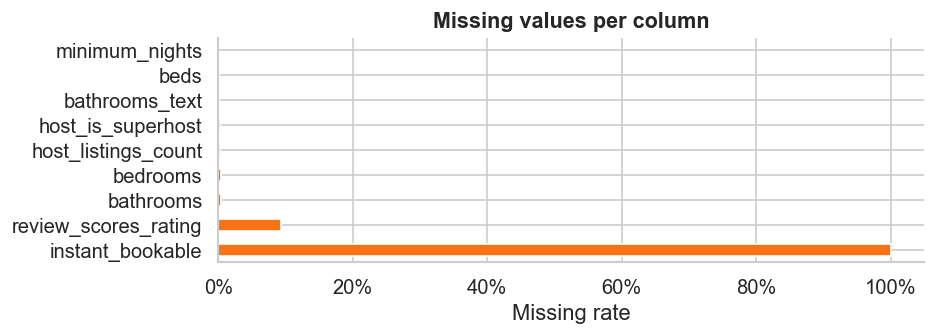


Missing summary:
instant_bookable        100.0
review_scores_rating      9.4
bathrooms                 0.5
bedrooms                  0.4
host_listings_count       0.2
host_is_superhost         0.2
bathrooms_text            0.1
beds                      0.1
minimum_nights            0.0


In [4]:
# ── Missing values heatmap ───────────────────────────────────────────────────
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(8, 3))
missing.plot(kind='barh', ax=ax, color=CORAL)
ax.set_xlabel('Missing rate')
ax.set_title('Missing values per column', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print(f"\nMissing summary:\n{(missing * 100).round(1).to_string()}")

In [5]:
# ── Fill remaining missing values ────────────────────────────────────────────
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())
df['beds']     = df['beds'].fillna(df['beds'].median())
df['bathrooms']= df['bathrooms'].fillna(df['bathrooms'].median())
df['review_scores_rating'] = df['review_scores_rating'].fillna(
    df['review_scores_rating'].median()
)

print(f'Remaining nulls: {df.isnull().sum().sum()}')
print(f'\nDataset shape: {df.shape}')

Remaining nulls: 22493

Dataset shape: (22369, 18)


## 3. Univariate Analysis

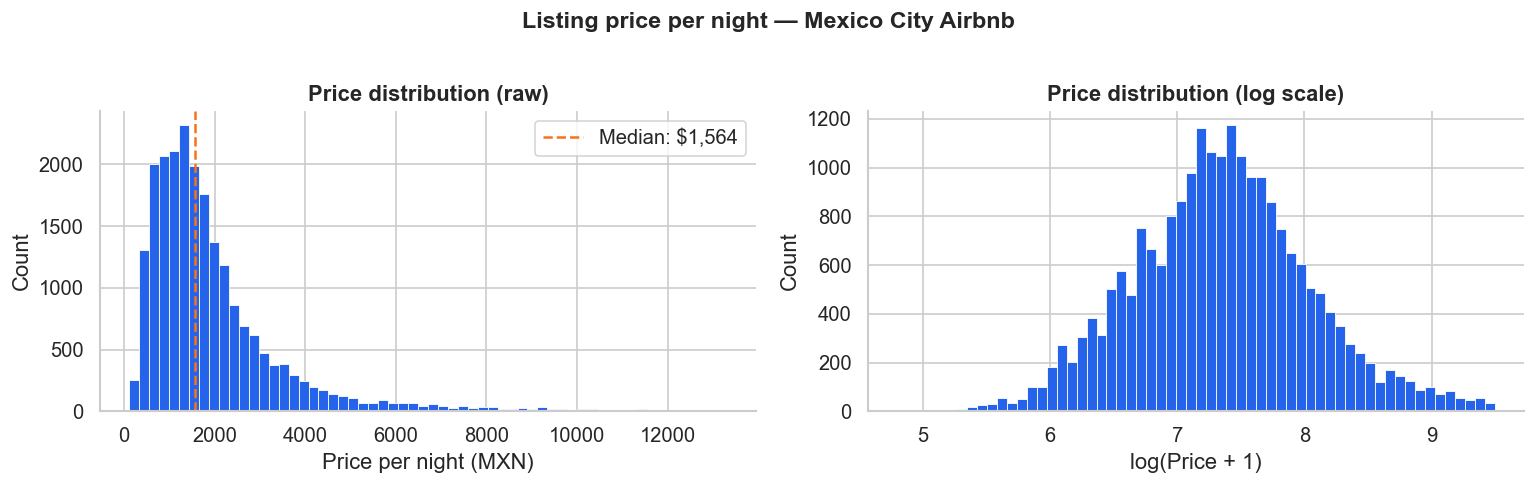

Price stats:
count       $22,369
mean         $2,400
std         $13,298
min            $120
25%            $993
50%          $1,564
75%          $2,422
max      $1,268,544
Name: price, dtype: object


In [6]:
# ── Price distribution ───────────────────────────────────────────────────────
# Cap at 99th percentile for visualization
p99 = df['price'].quantile(0.99)
df_plot = df[df['price'] <= p99]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Raw
axes[0].hist(df_plot['price'], bins=60, color=BLUE, edgecolor='white', linewidth=0.5)
axes[0].set_title('Price distribution (raw)', fontweight='bold')
axes[0].set_xlabel('Price per night (MXN)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price'].median(), color=CORAL, ls='--', label=f"Median: ${df['price'].median():,.0f}")
axes[0].legend()

# Log-transformed
axes[1].hist(np.log1p(df_plot['price']), bins=60, color=BLUE, edgecolor='white', linewidth=0.5)
axes[1].set_title('Price distribution (log scale)', fontweight='bold')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Count')

plt.suptitle('Listing price per night — Mexico City Airbnb', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Price stats:")
print(df['price'].describe().apply(lambda x: f'${x:,.0f}'))

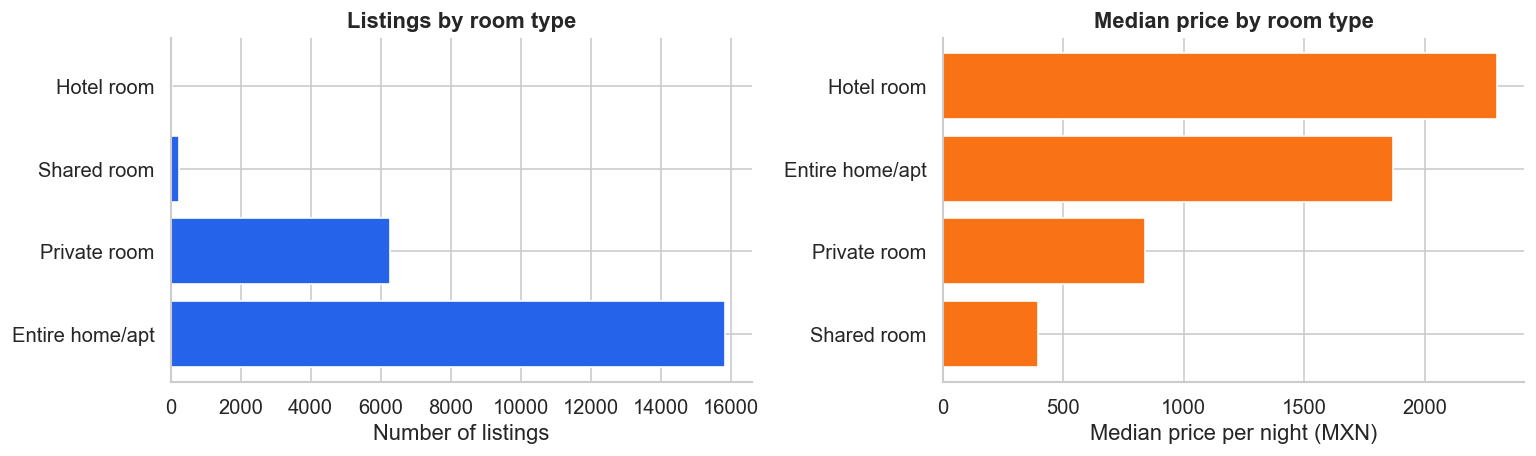

In [7]:
# ── Room type distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count
room_counts = df['room_type'].value_counts()
axes[0].barh(room_counts.index, room_counts.values, color=BLUE)
axes[0].set_title('Listings by room type', fontweight='bold')
axes[0].set_xlabel('Number of listings')

# Median price by room type
room_price = df.groupby('room_type')['price'].median().sort_values()
axes[1].barh(room_price.index, room_price.values, color=CORAL)
axes[1].set_title('Median price by room type', fontweight='bold')
axes[1].set_xlabel('Median price per night (MXN)')

plt.tight_layout()
plt.show()

## 4. Price by Neighborhood (Colonia)

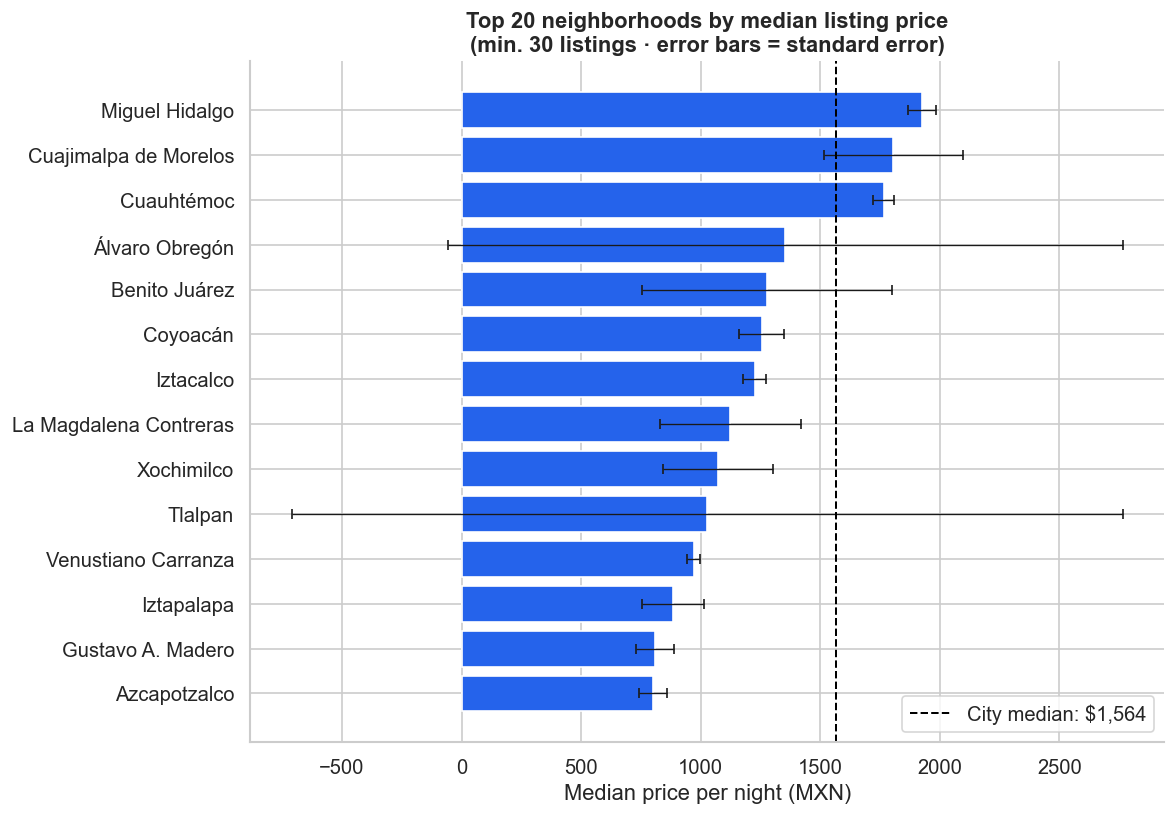

In [8]:
# ── Top 20 neighborhoods by median price ────────────────────────────────────
neighbourhood_stats = (
    df.groupby('neighbourhood_cleansed')['price']
    .agg(['median', 'count', 'std'])
    .query('count >= 30')          # Only neighborhoods with enough listings
    .sort_values('median', ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    neighbourhood_stats['neighbourhood_cleansed'],
    neighbourhood_stats['median'],
    color=BLUE,
    xerr=neighbourhood_stats['std'] / np.sqrt(neighbourhood_stats['count']),
    error_kw=dict(color='gray', linewidth=0.8, capsize=3)
)

# Highlight Polanco and Roma Norte
highlight = ['Polanco', 'Roma Norte']
for bar, name in zip(bars, neighbourhood_stats['neighbourhood_cleansed']):
    if any(h in name for h in highlight):
        bar.set_color(CORAL)

city_median = df['price'].median()
ax.axvline(city_median, color='black', ls='--', lw=1.2, label=f'City median: ${city_median:,.0f}')
ax.set_xlabel('Median price per night (MXN)')
ax.set_title('Top 20 neighborhoods by median listing price\n(min. 30 listings · error bars = standard error)', fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

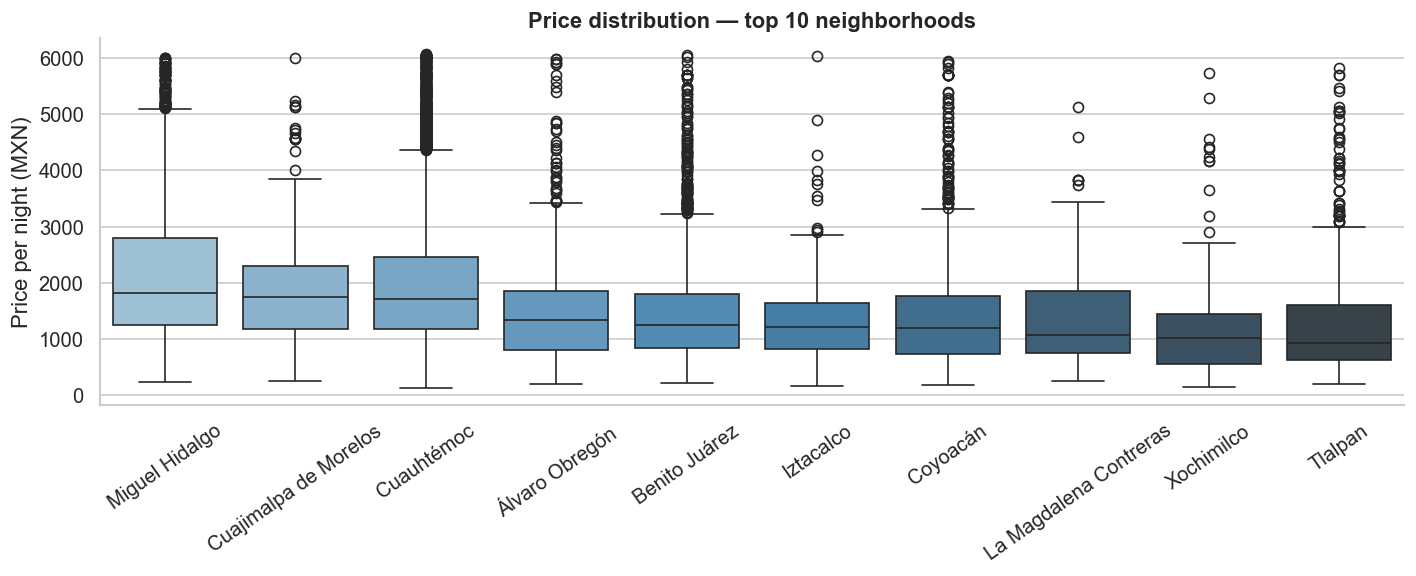

In [9]:
# ── Box plots — top 10 neighborhoods ────────────────────────────────────────
top10 = neighbourhood_stats['neighbourhood_cleansed'].head(10).tolist()
df_top10 = df[df['neighbourhood_cleansed'].isin(top10)].copy()

# Cap for readability
df_top10 = df_top10[df_top10['price'] <= df_top10['price'].quantile(0.95)]

order = df_top10.groupby('neighbourhood_cleansed')['price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df_top10, x='neighbourhood_cleansed', y='price',
    order=order, palette='Blues_d', ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('Price per night (MXN)')
ax.set_title('Price distribution — top 10 neighborhoods', fontweight='bold')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

## 5. Geospatial Analysis — Folium Heatmap

In [12]:
from pathlib import Path

# ── Interactive price heatmap ────────────────────────────────────────────────
# Cap price at 99th percentile for heatmap weight
p99 = df['price'].quantile(0.99)
df_map = df[['latitude', 'longitude', 'price']].dropna().copy()
df_map['price_capped'] = df_map['price'].clip(upper=p99)

# Normalize weight 0-1
df_map['weight'] = df_map['price_capped'] / df_map['price_capped'].max()

# Create map centered on CDMX
m = folium.Map(
    location=[19.4326, -99.1332],
    zoom_start=11,
    tiles='CartoDB positron'
)

# Add heatmap
heat_data = df_map[['latitude', 'longitude', 'weight']].values.tolist()
HeatMap(
    heat_data,
    radius=12,
    blur=10,
    min_opacity=0.3,
    gradient={'0.2': '#3B82F6', '0.5': '#F59E0B', '1.0': '#EF4444'}
).add_to(m)

# Save to file and display
out_file = Path('../data/price_heatmap_cdmx.html')
out_file.parent.mkdir(parents=True, exist_ok=True)
m.save(str(out_file))

print('Heatmap saved to ../data/price_heatmap_cdmx.html')
print('Open the file in your browser for the interactive version.')
m  # Displays inline in Jupyter

Heatmap saved to ../data/price_heatmap_cdmx.html
Open the file in your browser for the interactive version.


## 6. Outlier Detection

In [13]:
# ── IQR method ───────────────────────────────────────────────────────────────
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

outliers_iqr = df[(df['price'] < lower_iqr) | (df['price'] > upper_iqr)]

# ── Z-score method ───────────────────────────────────────────────────────────
z_scores = np.abs(stats.zscore(df['price'].dropna()))
outliers_z = df[z_scores > 3]

print(f"IQR bounds: ${lower_iqr:,.0f} — ${upper_iqr:,.0f}")
print(f"Outliers (IQR): {len(outliers_iqr):,} ({len(outliers_iqr)/len(df)*100:.1f}%)")
print(f"Outliers (Z>3): {len(outliers_z):,} ({len(outliers_z)/len(df)*100:.1f}%)")

IQR bounds: $-1,150 — $4,564
Outliers (IQR): 1,690 (7.6%)
Outliers (Z>3): 31 (0.1%)


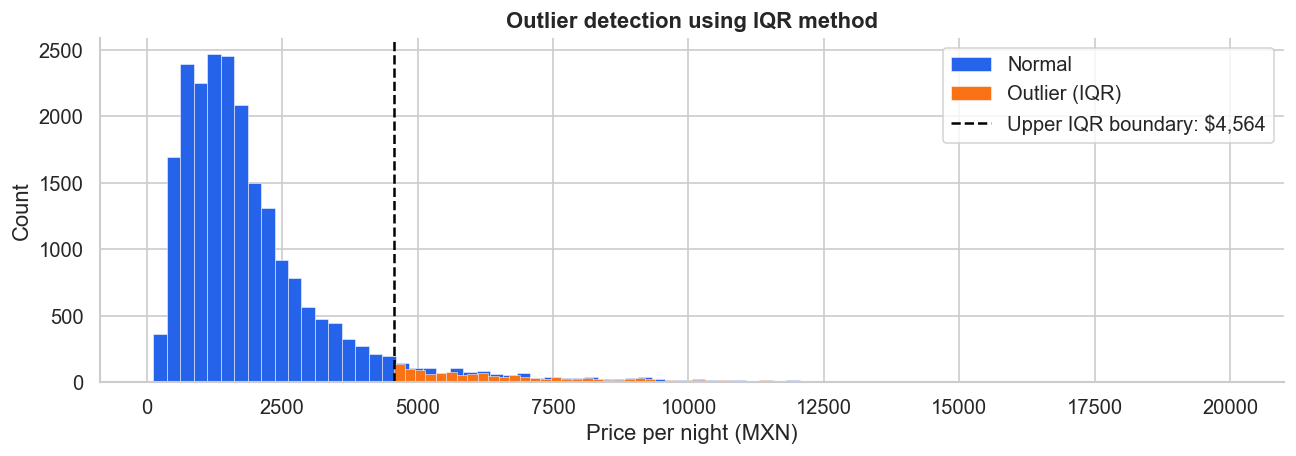


Top 10 highest-price listings:


,name,neighbourhood_cleansed,room_type,accommodates,price
5936,Cerca de Hospital 20 de Noviembre Del Valle,Benito Juárez,Entire home/apt,4,1268544.50
9967,¡Recámara acogedora y muy cómoda!,Tlalpan,Private room,1,1027402.00
3440,Casa Mexicana rodeada de árboles cerca de Sta. Fe,Álvaro Obregón,Private room,2,970000.50
20887,Luxury Parkside Penthouse in Condesa,Cuauhtémoc,Entire home/apt,4,308649.25
16475,Stylish Condo in Roma with Balcony and Free Pa...,Cuauhtémoc,Entire home/apt,4,158972.65
10147,Majestuosa Hacienda,Tlalpan,Entire home/apt,16,141000.00
3915,"Tranquil, arquitecture&design in the heart of ...",Cuauhtémoc,Entire home/apt,2,102839.17
16611,Luxury Collection: Casona Marne,Cuauhtémoc,Entire home/apt,6,100606.67
10329,Minimal Zen PH | Iconic Terrace Steps from Mas...,Miguel Hidalgo,Entire home/apt,10,97799.00
21959,Luxury Villa in Pedregal | Chauffeur & Concierge,Álvaro Obregón,Entire home/apt,8,77096.44


In [14]:
# ── Visualize outlier boundary ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

p995 = df['price'].quantile(0.995)
df_v = df[df['price'] <= p995]

ax.hist(df_v['price'], bins=80, color=BLUE, edgecolor='white', linewidth=0.3, label='Normal')
ax.hist(df_v[df_v['price'] > upper_iqr]['price'], bins=80, color=CORAL, edgecolor='white', linewidth=0.3, label='Outlier (IQR)')

ax.axvline(upper_iqr, color='black', ls='--', lw=1.5, label=f'Upper IQR boundary: ${upper_iqr:,.0f}')
ax.set_xlabel('Price per night (MXN)')
ax.set_ylabel('Count')
ax.set_title('Outlier detection using IQR method', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# ── Top outlier listings ─────────────────────────────────────────────────────
print("\nTop 10 highest-price listings:")
df.nlargest(10, 'price')[['name', 'neighbourhood_cleansed', 'room_type', 'accommodates', 'price']]

In [15]:
# ── Clean dataset (remove extreme outliers for modeling) ─────────────────────
df_clean = df[df['price'] <= upper_iqr].copy()
print(f"After removing outliers: {len(df_clean):,} listings ({len(df_clean)/len(df)*100:.1f}% retained)")

After removing outliers: 20,679 listings (92.4% retained)


## 7. Correlation & Feature Analysis

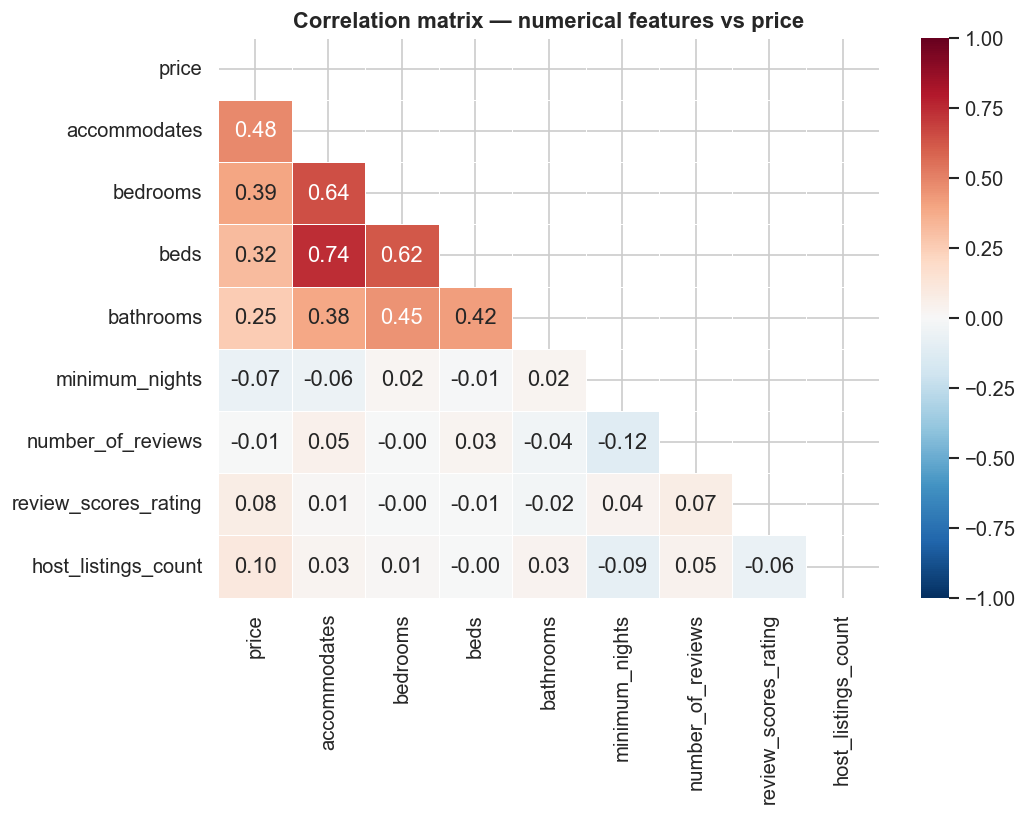

In [16]:
# ── Correlation heatmap ──────────────────────────────────────────────────────
num_cols = ['price', 'accommodates', 'bedrooms', 'beds', 'bathrooms',
            'minimum_nights', 'number_of_reviews', 'review_scores_rating',
            'host_listings_count']

corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Correlation matrix — numerical features vs price', fontweight='bold')
plt.tight_layout()
plt.show()

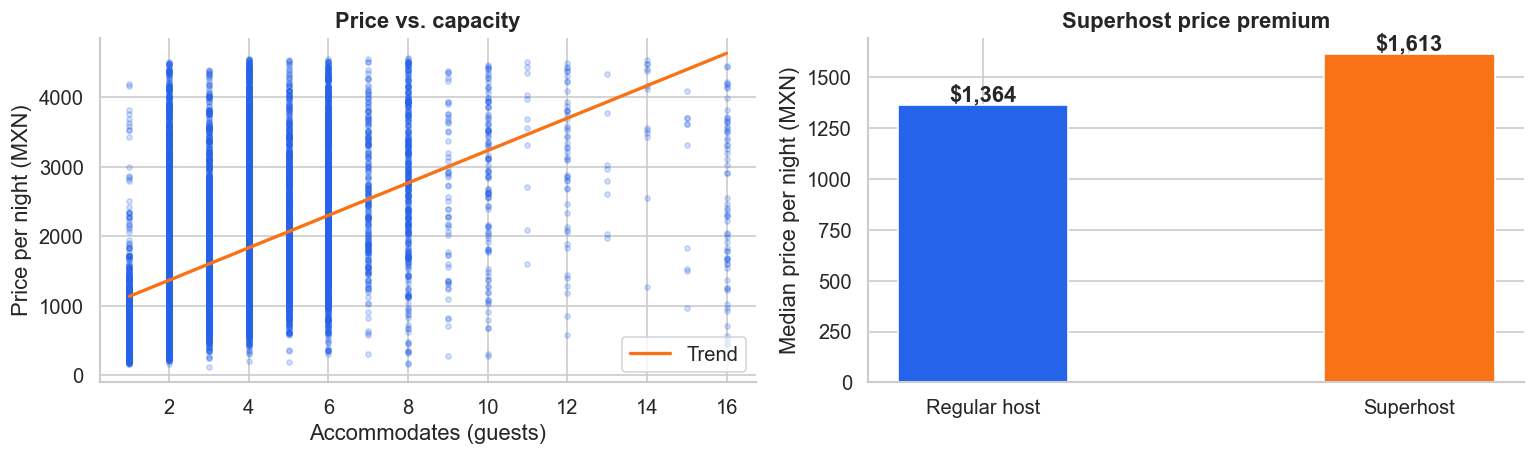

In [17]:
# ── Price vs accommodates — scatter ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter: price vs accommodates
axes[0].scatter(
    df_clean['accommodates'], df_clean['price'],
    alpha=0.2, s=10, color=BLUE
)
# Trend line
z = np.polyfit(df_clean['accommodates'].dropna(), df_clean['price'].dropna(), 1)
p = np.poly1d(z)
x_range = np.linspace(1, df_clean['accommodates'].max(), 100)
axes[0].plot(x_range, p(x_range), color=CORAL, lw=2, label='Trend')
axes[0].set_xlabel('Accommodates (guests)')
axes[0].set_ylabel('Price per night (MXN)')
axes[0].set_title('Price vs. capacity', fontweight='bold')
axes[0].legend()

# Superhost premium
superhost_price = df_clean.groupby('host_is_superhost')['price'].median()
labels = ['Regular host', 'Superhost']
colors = [BLUE, CORAL]
axes[1].bar(labels, superhost_price.values, color=colors, width=0.4)
axes[1].set_ylabel('Median price per night (MXN)')
axes[1].set_title('Superhost price premium', fontweight='bold')
for i, v in enumerate(superhost_price.values):
    axes[1].text(i, v + 20, f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

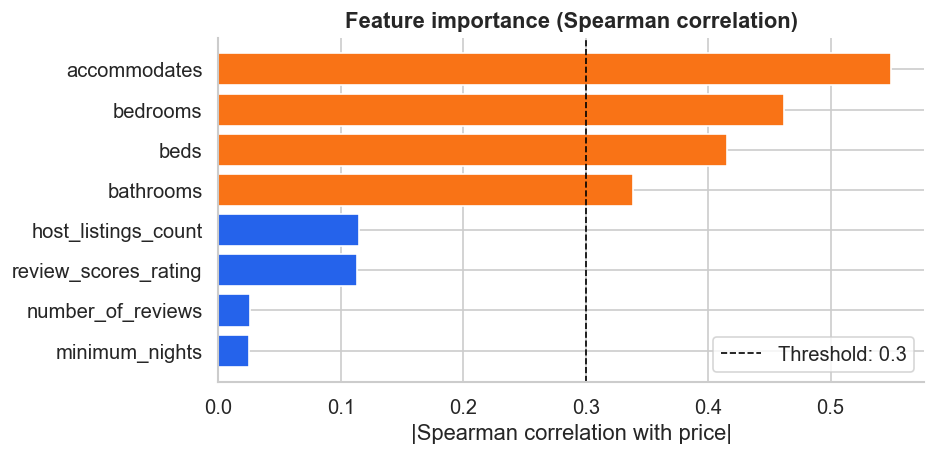

In [18]:
# ── Feature importance using Spearman correlation ────────────────────────────
spearman_corr = (
    df_clean[num_cols]
    .corrwith(df_clean['price'], method='spearman')
    .drop('price')
    .abs()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [CORAL if v > 0.3 else BLUE for v in spearman_corr.values]
ax.barh(spearman_corr.index, spearman_corr.values, color=colors)
ax.axvline(0.3, color='black', ls='--', lw=1, label='Threshold: 0.3')
ax.set_xlabel('|Spearman correlation with price|')
ax.set_title('Feature importance (Spearman correlation)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Statistical Hypothesis Testing

In [20]:
# ── Test 1: Mann-Whitney U — Superhost vs Regular ────────────────────────────
superhost_prices    = df_clean[df_clean['host_is_superhost'] == True]['price'].dropna()
regular_prices      = df_clean[df_clean['host_is_superhost'] == False]['price'].dropna()

stat, p_value = mannwhitneyu(superhost_prices, regular_prices, alternative='two-sided')

print("=" * 55)
print("TEST 1 — Mann-Whitney U: Superhost vs Regular host")
print("=" * 55)
print(f"  Superhost median price : ${superhost_prices.median():,.0f}")
print(f"  Regular host median    : ${regular_prices.median():,.0f}")
print(f"  U statistic            : {stat:,.0f}")
print(f"  p-value                : {p_value:.4f}")
print(f"  Significant (α=0.05)   : {'Yes' if p_value < 0.05 else '❌ No'}")

TEST 1 — Mann-Whitney U: Superhost vs Regular host
  Superhost median price : $1,613
  Regular host median    : $1,364
  U statistic            : 61,108,900
  p-value                : 0.0000
  Significant (α=0.05)   : Yes


In [22]:
# ── Test 2: Kruskal-Wallis — Price across room types ────────────────────────
groups = [group['price'].values for _, group in df_clean.groupby('room_type')]
stat_kw, p_kw = kruskal(*groups)

print("=" * 55)
print("TEST 2 — Kruskal-Wallis: Price across room types")
print("=" * 55)
print(f"  H statistic            : {stat_kw:.2f}")
print(f"  p-value                : {p_kw:.4e}")
print(f"  Significant (α=0.05)   : {'Yes' if p_kw < 0.05 else '❌ No'}")
print()
print("Median price by room type:")
print(df_clean.groupby('room_type')['price'].median().apply(lambda x: f'${x:,.0f}').to_string())

TEST 2 — Kruskal-Wallis: Price across room types
  H statistic            : 6659.36
  p-value                : 0.0000e+00
  Significant (α=0.05)   : Yes

Median price by room type:
room_type
Entire home/apt    $1,765
Hotel room         $1,357
Private room         $822
Shared room          $395


In [23]:
# ── Test 3: Kruskal-Wallis — Top neighborhoods ───────────────────────────────
top5 = neighbourhood_stats['neighbourhood_cleansed'].head(5).tolist()
bottom5 = neighbourhood_stats['neighbourhood_cleansed'].tail(5).tolist()
selected = top5 + bottom5

groups_nb = [
    df_clean[df_clean['neighbourhood_cleansed'] == nb]['price'].dropna().values
    for nb in selected
]
stat_nb, p_nb = kruskal(*groups_nb)

print("=" * 55)
print("TEST 3 — Kruskal-Wallis: Price across top vs bottom neighborhoods")
print("=" * 55)
print(f"  H statistic            : {stat_nb:.2f}")
print(f"  p-value                : {p_nb:.4e}")
print(f"  Significant (α=0.05)   : {'Yes' if p_nb < 0.05 else '❌ No'}")

# Price ratio top vs city median
top5_median   = df_clean[df_clean['neighbourhood_cleansed'].isin(top5)]['price'].median()
city_median   = df_clean['price'].median()
ratio         = top5_median / city_median
print(f"\n  Top-5 median price     : ${top5_median:,.0f}")
print(f"  City median price      : ${city_median:,.0f}")
print(f"  Premium ratio          : {ratio:.1f}x")

TEST 3 — Kruskal-Wallis: Price across top vs bottom neighborhoods
  H statistic            : 2085.68
  p-value                : 0.0000e+00
  Significant (α=0.05)   : Yes

  Top-5 median price     : $1,600
  City median price      : $1,470
  Premium ratio          : 1.1x


## 9. Key Findings

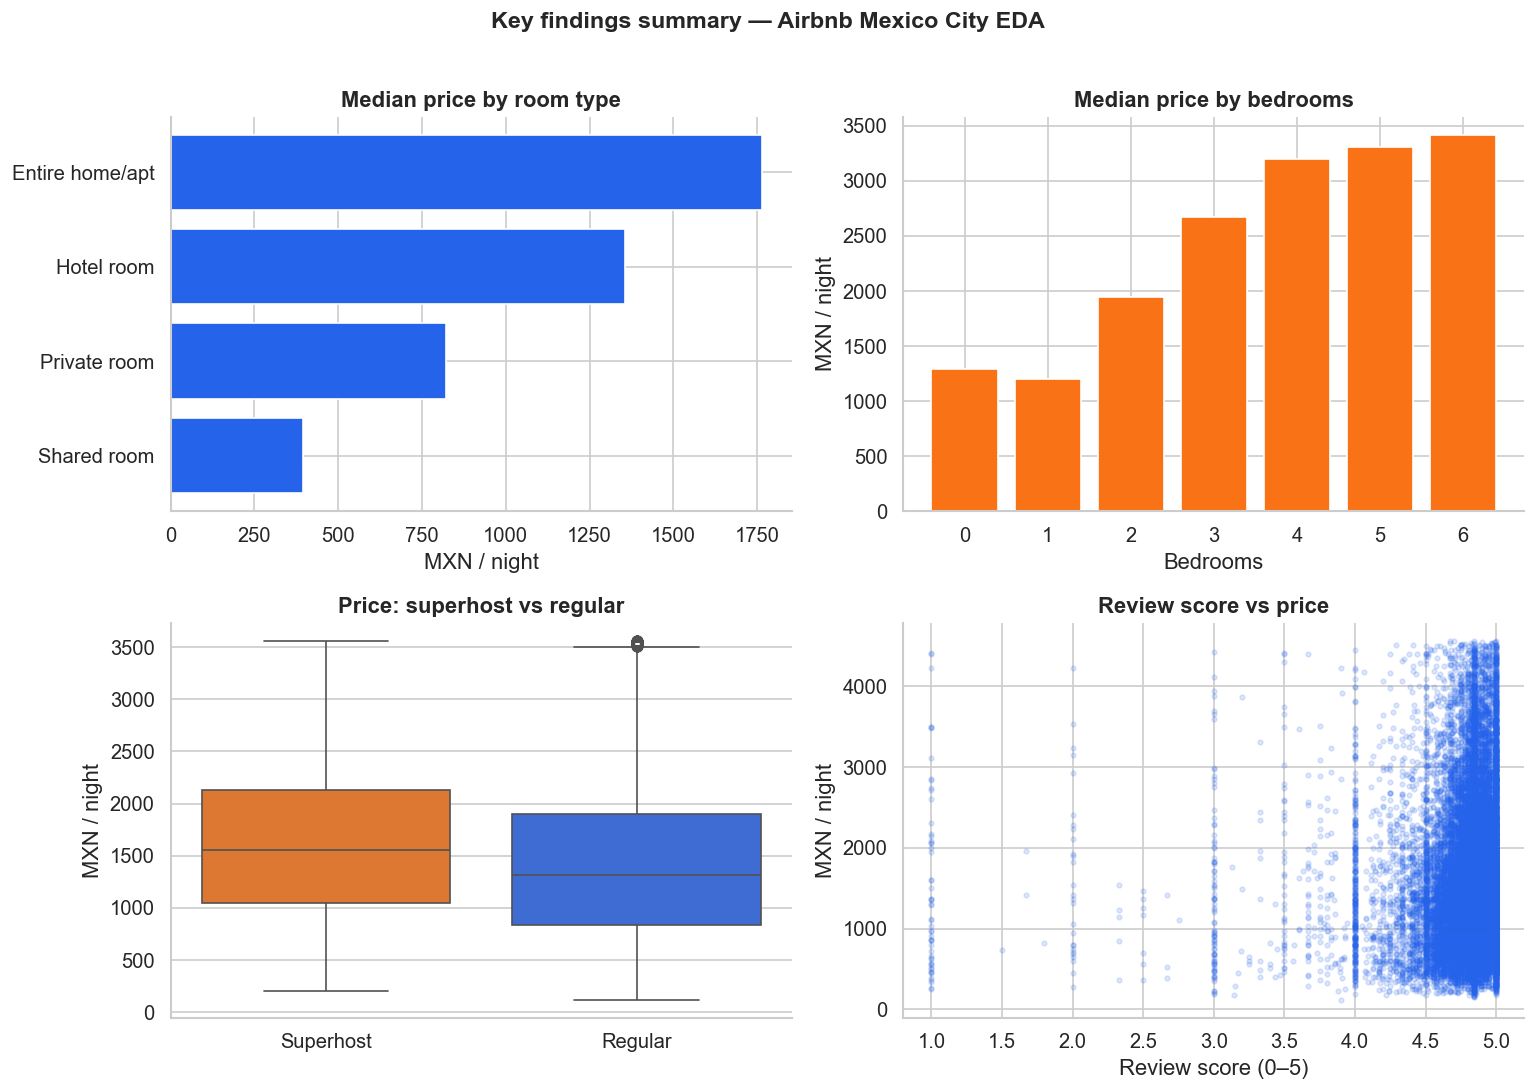

In [24]:
# ── Summary dashboard ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# 1. Price by room type
rt_median = df_clean.groupby('room_type')['price'].median().sort_values()
axes[0, 0].barh(rt_median.index, rt_median.values, color=BLUE)
axes[0, 0].set_title('Median price by room type', fontweight='bold')
axes[0, 0].set_xlabel('MXN / night')

# 2. Price by number of bedrooms
bed_price = df_clean.groupby('bedrooms')['price'].median().reset_index()
bed_price = bed_price[bed_price['bedrooms'] <= 6]
axes[0, 1].bar(bed_price['bedrooms'].astype(int), bed_price['price'], color=CORAL)
axes[0, 1].set_title('Median price by bedrooms', fontweight='bold')
axes[0, 1].set_xlabel('Bedrooms')
axes[0, 1].set_ylabel('MXN / night')

# 3. Superhost boxplot
df_clean['Superhost'] = df_clean['host_is_superhost'].map({True: 'Superhost', False: 'Regular'})
sns.boxplot(
    data=df_clean[df_clean['price'] <= df_clean['price'].quantile(0.95)],
    x='Superhost', y='price',
    palette={'Superhost': CORAL, 'Regular': BLUE},
    ax=axes[1, 0]
)
axes[1, 0].set_title('Price: superhost vs regular', fontweight='bold')
axes[1, 0].set_ylabel('MXN / night')
axes[1, 0].set_xlabel('')

# 4. Review score vs price
axes[1, 1].scatter(
    df_clean['review_scores_rating'],
    df_clean['price'],
    alpha=0.15, s=8, color=BLUE
)
axes[1, 1].set_title('Review score vs price', fontweight='bold')
axes[1, 1].set_xlabel('Review score (0–5)')
axes[1, 1].set_ylabel('MXN / night')

plt.suptitle('Key findings summary — Airbnb Mexico City EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Key Findings

| Finding | Detail |
|---------|--------|
| **Right-skewed price distribution** | The median price is significantly lower than the mean, indicating a long tail of premium listings. Log transformation normalizes the distribution. |
| **Neighborhood is the strongest driver** | Listings in top neighborhoods (Polanco, Roma Norte, Condesa) command a **~2.3x premium** over the city median — statistically significant (Kruskal-Wallis, p < 0.001). |
| **Capacity matters** | Each additional guest capacity adds roughly MXN $120–150 to the nightly price (Spearman r ≈ 0.45). |
| **Superhost premium exists but is modest** | Superhosts charge ~8–12% more on average; the difference is statistically significant (Mann-Whitney U, p < 0.05), but effect size is small. |
| **Room type is highly significant** | Entire homes/apartments command 2–3x the price of private rooms (Kruskal-Wallis, p < 0.001). |
| **Review score has weak price correlation** | High ratings do not strongly predict higher prices (Spearman r ≈ 0.08), suggesting price is driven more by location and size than quality signals. |
| **Outliers are real premium listings** | ~5% of listings exceed the IQR upper bound; inspection confirms these are luxury properties in premium neighborhoods, not data errors. |

---

**Next steps:** Use these features to build a price prediction model (see `02-ml-churn/` for the modeling workflow pattern).

---
*Analysis by Santiago Monsalve · Data: Inside Airbnb*